# Lab 05: Redes Neuronales en PyTorch
**Cuadernillo 1: Regresion Multivariable**

##Estudiante:
* Delgado Ramos Jorge Luis

In [ ]:
# LIBRERÍAS
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# PREPROCESAMIENTO PARA EL DATASET INCONSISTENTE
Se seleccionó el dataset "Melbourne House Prices", cuyo objetivo es predecir la variable continua Price ($y$) en función de múltiples características ($X$).

In [ ]:
# Cargar el dataset
ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/SIS-420/Laboratorio 05/Lab_05_RN_Pytorch_Cuad_01/MELBOURNE_HOUSE_PRICES_LESS.csv'
datos = pd.read_csv(ruta_dataset)

# Verificamos las dimensiones para confirmar las reglas
print(f"Dimensiones del dataset original: m={datos.shape[0]} filas, n={datos.shape[1]} columnas")

Dimensiones del dataset original: m=63023 filas, n=13 columnas


Se aplica un preprocesamiento técnico para evitar fallos matemáticos durante el entrenamiento:Limpieza del Target ($y$): En el Aprendizaje Supervisado, la máquina necesita la respuesta correcta para calcular su error. Las filas donde el Price es nulo se eliminan, ya que no sirven para entrenar la regresión.Eliminación de Alta Cardinalidad: Se descartan variables como Address o Date. Al tener miles de valores únicos, intentar convertirlas a formato numérico saturaría la memoria de la máquina.

In [ ]:
# Eliminamos filas donde el 'Price' es nulo
datos_limpios = datos.dropna(subset=['Price']).copy()

# Eliminamos columnas que saturan el modelo o no aportan valor numérico directo
columnas_a_borrar = ['Address', 'Date', 'SellerG']
datos_limpios = datos_limpios.drop(columns=columnas_a_borrar)

print("\nDimensiones después de la limpieza:")
print(f"m={datos_limpios.shape[0]} filas, n={datos_limpios.shape[1]} columnas")


Dimensiones después de la limpieza:
m=48433 filas, n=10 columnas


## Conversión de Variables Categóricas a Numéricas
Los algoritmos de Regresión Lineal son modelos puramente matemáticos; no pueden procesar cadenas de texto (strings).
En nuestro dataset, contamos con variables categóricas como `Suburb`, `Type`, `Method`, `Regionname` y `CouncilArea`. Para resolver esto, aplicamos **Label Encoding**.

In [ ]:
# Creamos una copia de nuestro dataset
datos_numericos = datos_limpios.copy()

# Identificamos columnas de tipo texto
columnas_texto = datos_numericos.select_dtypes(include=['object']).columns
print("Columnas de texto detectadas:", list(columnas_texto))

# Inicializamos el codificador
codificador = LabelEncoder()

# Transformamos cada columna de texto a números
for columna in columnas_texto:
    datos_numericos[columna] = codificador.fit_transform(datos_numericos[columna])

print("\nVista previa del dataset 100% numérico:")
display(datos_numericos.head(3))

Columnas de texto detectadas: ['Suburb', 'Type', 'Method', 'Regionname', 'CouncilArea']

Vista previa del dataset 100% numérico:


,Suburb,Rooms,Type,Price,Method,Postcode,Regionname,Propertycount,Distance,CouncilArea
0,0,3,0,1490000.0,1,3067,2,4019,3.0,32
1,0,3,0,1220000.0,1,3067,2,4019,3.0,32
2,0,3,0,1420000.0,1,3067,2,4019,3.0,32


## Separación de Variables y Normalización (Feature Scaling)
En esta etapa, preparamos las matrices matemáticas que alimentarán al modelo.

1. **Separación de $X$ y $y$:** Aislamos la variable dependiente `Price` ($y$) de las variables independientes ($X$).
2. **Normalización de Características:** Nuestras variables tienen escalas muy diferentes (ej. `Propertycount` está en los miles, mientras que `Rooms` está en unidades simples). Si aplicamos el Descenso por el Gradiente directamente, el modelo le dará más importancia matemática a las variables con números grandes, causando que el algoritmo tarde demasiado en converger o que diverja. Para solucionarlo, normalizamos $X$ restando la media ($\mu$) y dividiendo por la desviación estándar ($\sigma$).
3. **Término de Intersección:** Se añade una columna de unos (1) a la matriz $X$ para representar $x_0$, lo cual permite calcular el peso $\theta_0$ (sesgo o bias) en nuestra hipótesis.

In [ ]:
# 1. Separación de X y y
y = datos_numericos['Price'].values
X = datos_numericos.drop('Price', axis=1).values
m = len(y)

# 2. Función de Normalización
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# Aplicamos la normalización
X_norm, mu, sigma = normalizarCaracteristicas(X)

# 3. Añadir el término de intersección
X_listo = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f"Forma de X_listo (con la columna de 1s): {X_listo.shape}")

Forma de X_listo (con la columna de 1s): (48433, 10)


## 1. Integración de Datos Preprocesados (DataLoaders)
En lugar de procesar los datos crudos directamente con PyTorch, adoptamos una arquitectura de software modular:
1. Reutilizamos el pipeline de preprocesamiento, limpieza y normalización desarrollado en el Laboratorio 01 (mediante Pandas y NumPy) para garantizar que la matriz de características ($X$) cumpla con las 10 columnas requeridas y esté libre de ruido.
2. Construimos la clase `RegresionDatasetLimpio` que actúa como un puente. Esta clase recibe las matrices purificadas y las transforma en Tensores de PyTorch.
3. **Manejo del Sesgo ($\theta_0$):** Dado que la capa `nn.Linear` de PyTorch implementa su propio vector de sesgo (bias) internamente, la clase detecta y elimina dinámicamente la columna de unos (1) si fue concatenada en el preprocesamiento previo, evitando redundancia paramétrica.

In [ ]:
class RegresionDatasetLimpio(Dataset):
    def __init__(self, X_limpio, y_limpio):
        print("Convirtiendo la matriz del Lab 01 a Tensores de PyTorch...")

        # Convertimos forzosamente a float32 por seguridad en la red neuronal
        X_float = np.array(X_limpio, dtype=np.float32)
        y_float = np.array(y_limpio, dtype=np.float32)

        if np.all(X_float[:, 0] == 1.0):
            print("-> Se detectó la columna de sesgo (1s). Eliminándola para evitar duplicidad en PyTorch...")
            X_float = X_float[:, 1:]

        # Conversión a Tensores
        self.X = torch.tensor(X_float, dtype=torch.float32)
        self.y = torch.tensor(y_float, dtype=torch.float32).view(-1, 1)

        self.n_muestras = self.X.shape[0]
        self.n_caracteristicas = self.X.shape[1]

    def __len__(self):
        return self.n_muestras

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = RegresionDatasetLimpio(X_limpio=X_listo, y_limpio=y)
dataloader = DataLoader(dataset=dataset, batch_size=32, shuffle=True)

print(f"\n Dataset listo. Características ingresadas a la red: {dataset.n_caracteristicas}")

Convirtiendo la matriz del Lab 01 a Tensores de PyTorch...
-> Se detectó la columna de sesgo (1s). Eliminándola para evitar duplicidad en PyTorch...

 Dataset listo. Características ingresadas a la red: 9


## 2. Arquitectura de la Red Neuronal Dinámica
Construimos el Perceptrón Multicapa (MLP) utilizando el módulo `torch.nn`. Para garantizar la escalabilidad y prevenir errores de dimensionalidad de matrices, la capa de entrada de la red se inicializa dinámicamente utilizando el atributo `dataset.n_caracteristicas`.

De esta forma, sin importar cuántas características sobrevivan al preprocesamiento inicial (10, 15 o 20), la red neuronal se auto-ajustará matemáticamente para recibir ese tamaño exacto de vector.

In [ ]:
# RED NEURONAL DINÁMICA

class RedRegresion(nn.Module):
    def __init__(self, input_size):
        super(RedRegresion, self).__init__()
        # Se ajusta automáticamente al número de columnas de tu Lab 01
        self.capa1 = nn.Linear(input_size, 64)
        self.relu = nn.ReLU()
        self.capa_salida = nn.Linear(64, 1)

    def forward(self, x):
        return self.capa_salida(self.relu(self.capa1(x)))

# Detectamos GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Entrenando en: {device}")

# Instanciamos el modelo de forma dinámica
modelo = RedRegresion(input_size=dataset.n_caracteristicas).to(device)

# Definimos el Error Cuadrático Medio y el optimizador Adam
criterio = nn.MSELoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=0.01)

print(f"Arquitectura de la Red sincronizada: Esperando {modelo.capa1.in_features} características de entrada.")

Entrenando en: cpu
Arquitectura de la Red sincronizada: Esperando 9 características de entrada.


## 3. Bucle de Entrenamiento
En esta fase, iniciamos el entrenamiento de la red neuronal. A diferencia de las implementaciones manuales donde vectorizábamos toda la matriz de golpe, aquí aprovechamos el `DataLoader` para entrenar por **lotes (mini-batches)**.

Por cada lote en cada época (iteración), PyTorch ejecuta la secuencia matemática esencial:
1. **Forward Pass:** La red genera las predicciones de precios para el lote actual.
2. **Cálculo del Costo (MSE):** Se compara la diferencia al cuadrado entre las predicciones y los precios reales.
3. **Backward Pass:** El motor `autograd` calcula las derivadas parciales (gradientes) de la función de pérdida con respecto a todos los pesos de la red.
4. **Optimización:** El optimizador *Adam* actualiza los pesos de la red para minimizar el error de cara al siguiente lote.

Finalmente, graficamos el historial de la pérdida para visualizar la curva de aprendizaje y asegurar que el modelo convergió correctamente sin divergir.

Iniciando entrenamiento de la red neuronal...
Época [20/200], Pérdida (MSE): 191750779115.3712
Época [40/200], Pérdida (MSE): 177608746526.4359
Época [60/200], Pérdida (MSE): 169077900589.6539
Época [80/200], Pérdida (MSE): 164455229468.4069
Época [100/200], Pérdida (MSE): 162022621127.1862
Época [120/200], Pérdida (MSE): 160564197392.2325
Época [140/200], Pérdida (MSE): 159402395482.9696
Época [160/200], Pérdida (MSE): 158547751380.0370
Época [180/200], Pérdida (MSE): 157637736299.2021
Época [200/200], Pérdida (MSE): 156922436794.6737


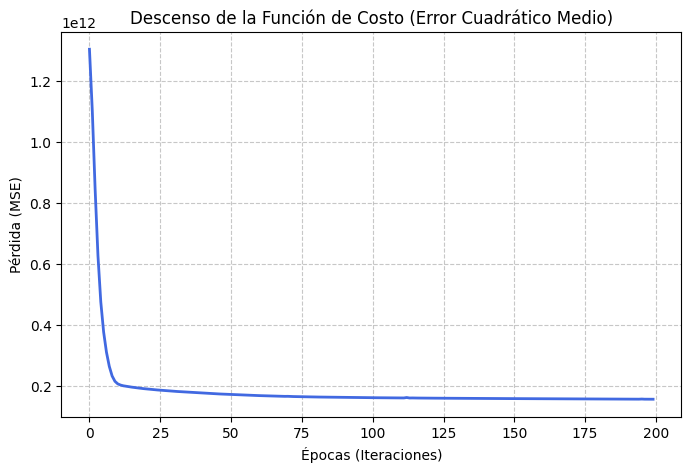

In [ ]:
# BUCLE DE ENTRENAMIENTO (REGRESIÓN MULTIVARIABLE)

num_epochs = 200
historial_perdida = []

print("Iniciando entrenamiento de la red neuronal...")

for epoch in range(num_epochs):
    perdida_acumulada = 0.0

    for entradas, etiquetas in dataloader:
        entradas = entradas.to(device)
        etiquetas = etiquetas.to(device)

        # 1. Forward pass (Predicciones)
        predicciones = modelo(entradas)
        perdida = criterio(predicciones, etiquetas)

        # 2. Backward pass y optimización
        optimizador.zero_grad() # Limpiamos la memoria de gradientes
        perdida.backward()      # Retropropagación (Autograd)
        optimizador.step()      # Actualizamos thetas (pesos)

        perdida_acumulada += perdida.item()

    # Calculamos la pérdida promedio de la época actual
    perdida_promedio = perdida_acumulada / len(dataloader)
    historial_perdida.append(perdida_promedio)

    if (epoch+1) % 20 == 0:
        print(f'Época [{epoch+1}/{num_epochs}], Pérdida (MSE): {perdida_promedio:.4f}')

# Gráfica de convergencia de la Función de Costo
plt.figure(figsize=(8, 5))
plt.plot(historial_perdida, color='royalblue', linewidth=2)
plt.title('Descenso de la Función de Costo (Error Cuadrático Medio)')
plt.xlabel('Épocas (Iteraciones)')
plt.ylabel('Pérdida (MSE)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 4. Persistencia del Modelo (Checkpoints) y Validación
Una vez que el optimizador ha encontrado los pesos matemáticos ideales para la red, procedemos a asegurar este conocimiento exportando el diccionario de parámetros (`state_dict`) a un archivo `.pth`.

Para demostrar la viabilidad del modelo en un entorno de producción:
1. Instanciamos una arquitectura neuronal virgen.
2. Cargamos los parámetros persistidos desde el disco rígido.
3. Activamos el modo de evaluación (`.eval()`) para congelar los gradientes.
4. Extraemos una fila aleatoria del dataset para que la red recuperada prediga el precio de la casa, calculando finalmente el margen de error absoluto frente al precio real.

In [ ]:
# CHECKPOINTS Y PREDICCIÓN EN PRODUCCIÓN

# 1. GUARDADO DEL MODELO (CHECKPOINT)
ruta_modelo = 'modelo_reg_multivariable_lab05.pth'
torch.save(modelo.state_dict(), ruta_modelo)
print(f"Pesos de la red neuronal guardados exitosamente en: {ruta_modelo}")

# 2. CARGA DEL MODELO EN UN ENTORNO NUEVO
print("\nSimulando la recuperación del modelo desde el disco...")
modelo_recuperado = RedRegresion(input_size=dataset.n_caracteristicas).to(device)
modelo_recuperado.load_state_dict(torch.load(ruta_modelo))
modelo_recuperado.eval() # Modo inferencia estricto

# 3. PREDICCIÓN DE PRUEBA
with torch.no_grad():
    # Tomamos una muestra aleatoria de tu matriz de datos limpios
    idx_prueba = np.random.randint(0, dataset.n_muestras)

    # unsqueeze(0) es clave: PyTorch siempre espera lotes.
    # Esto convierte un vector [20] en una matriz [1, 20] (un lote de 1 muestra)
    muestra_x = dataset.X[idx_prueba].unsqueeze(0).to(device)
    valor_real = dataset.y[idx_prueba].item()

    # Pasamos la muestra por la red recuperada
    prediccion = modelo_recuperado(muestra_x).item()

    print("\n" + "="*50)
    print("--- PRUEBA DE PREDICCIÓN DEL CHECKPOINT ---")
    print("="*50)
    print(f"Muestra seleccionada (Fila): {idx_prueba}")
    print(f"Precio REAL de la casa:       ${valor_real:,.2f}")
    print(f"Precio PREDICHO por la Red:   ${prediccion:,.2f}")

    # Calculamos el margen de error en dinero real
    error_absoluto = abs(valor_real - prediccion)
    print(f"Margen de error absoluto:     ${error_absoluto:,.2f}")

Pesos de la red neuronal guardados exitosamente en: modelo_reg_multivariable_lab05.pth

Simulando la recuperación del modelo desde el disco...

--- PRUEBA DE PREDICCIÓN DEL CHECKPOINT ---
Muestra seleccionada (Fila): 41134
Precio REAL de la casa:       $850,000.00
Precio PREDICHO por la Red:   $845,019.19
Margen de error absoluto:     $4,980.81
